DOE Simulation

In [4]:
import pandas as pd
import numpy as np

# Define ranges
crosslinker = [0, 1, 2]
wax = [0, 1]
Tg = [25, 30, 35]
solids = [30, 32, 35]

# Create factorial design
doe = pd.DataFrame([
    [c, w, t, s]
    for c in crosslinker
    for w in wax
    for t in Tg
    for s in solids
], columns=["crosslinker_pct", "wax_pct", "Tg_C", "solids_pct"])

doe

,crosslinker_pct,wax_pct,Tg_C,solids_pct
0,0,0,25,30
1,0,0,25,32
2,0,0,25,35
3,0,0,30,30
4,0,0,30,32
5,0,0,30,35
6,0,0,35,30
7,0,0,35,32
8,0,0,35,35
9,0,1,25,30


Simulate Experimental Results

In [6]:
def simulate_taber(row):
    return (
        100
        - 20 * row["crosslinker_pct"]
        - 10 * row["wax_pct"]
        + 0.5 * (row["Tg_C"] - 25)
        + np.random.normal(0, 3)
    )

doe["taber_loss_mg"] = doe.apply(simulate_taber, axis=1)

doe

,crosslinker_pct,wax_pct,Tg_C,solids_pct,taber_loss_mg
0,0,0,25,30,99.036730
1,0,0,25,32,100.623581
2,0,0,25,35,98.222538
3,0,0,30,30,99.642711
4,0,0,30,32,101.679766
5,0,0,30,35,102.256926
6,0,0,35,30,99.576381
7,0,0,35,32,103.292554
8,0,0,35,35,106.175906
9,0,1,25,30,90.144710


Train Model on DOE Data

In [8]:
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

X = doe.drop("taber_loss_mg", axis=1)
y = doe["taber_loss_mg"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = XGBRegressor()
model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


Generate New Candidate Formulations

In [9]:
# Generate random formulations
candidates = pd.DataFrame({
    "crosslinker_pct": np.random.uniform(0, 2, 100),
    "wax_pct": np.random.uniform(0, 1, 100),
    "Tg_C": np.random.uniform(25, 35, 100),
    "solids_pct": np.random.uniform(30, 35, 100)
})

Predict Performance

In [10]:
candidates["predicted_taber"] = model.predict(candidates)

# Sort best (lowest Taber loss = better)
top_candidates = candidates.sort_values("predicted_taber").head(5)

top_candidates

,crosslinker_pct,wax_pct,Tg_C,solids_pct,predicted_taber
63,1.479103,0.714544,28.812480,33.842176,82.8769
36,1.407074,0.567604,27.810254,33.046658,82.8769
3,1.642379,0.097171,25.872064,32.940688,82.8769
89,1.318142,0.613578,26.244178,33.021716,82.8769
38,1.774665,0.879760,27.705181,33.398282,82.8769


Second DOE (Focused Optimization)

In [11]:
best = top_candidates.iloc[0]

focused_doe = pd.DataFrame({
    "crosslinker_pct": np.linspace(best["crosslinker_pct"] - 0.5, best["crosslinker_pct"] + 0.5, 5),
    "wax_pct": np.linspace(best["wax_pct"] - 0.2, best["wax_pct"] + 0.2, 5),
    "Tg_C": np.linspace(best["Tg_C"] - 2, best["Tg_C"] + 2, 5),
    "solids_pct": np.linspace(best["solids_pct"] - 2, best["solids_pct"] + 2, 5)
})

focused_doe

,crosslinker_pct,wax_pct,Tg_C,solids_pct
0,0.979103,0.514544,26.81248,31.842176
1,1.229103,0.614544,27.81248,32.842176
2,1.479103,0.714544,28.81248,33.842176
3,1.729103,0.814544,29.81248,34.842176
4,1.979103,0.914544,30.81248,35.842176


DOE Visualization

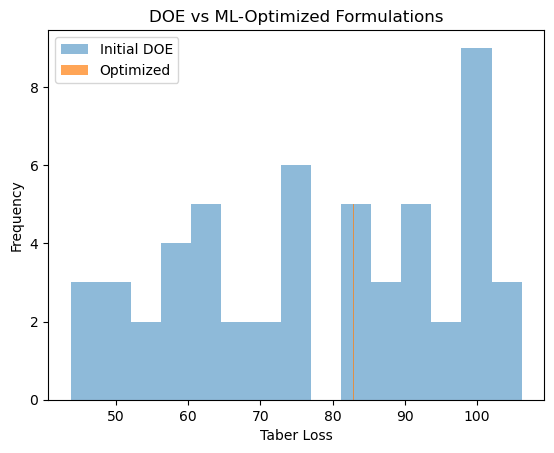

In [12]:
import matplotlib.pyplot as plt

plt.hist(doe["taber_loss_mg"], bins=15, alpha=0.5, label="Initial DOE")
plt.hist(top_candidates["predicted_taber"], bins=5, alpha=0.7, label="Optimized")

plt.xlabel("Taber Loss")
plt.ylabel("Frequency")
plt.legend()
plt.title("DOE vs ML-Optimized Formulations")
plt.show()